# Deep Soil Exponential Hydraulic Conductivity Profiles

This notebook defines the expected `deep_properties` structure locally, then assigns exponential-profile parameters explicitly in the notebook and plots

$$K(z) = (K_{max} - K_{min}) \, e^{-fz} + K_{min}$$

for each soil type down to its assigned maximum depth.

## 1. Import Libraries and Set Paths

In [ ]:
from pathlib import Path
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import importlib
io_path = str(Path(os.getenv('PROJECT_FOLDER')))

project_root = Path.cwd().parent
scripts_folder = project_root / 'scripts'

fig_dir = os.path.join(io_path, 'krycklan', 'figs')

sys.path.insert(0, str(project_root))
sys.path.insert(0, str(scripts_folder))

from soil_helpers import (
    discretized_depths, round_sig, expand_pf_layers,
    deep_properties_function_text, org_properties_function_text, root_properties_function_text,
    wrc,
)

## 2. Define the Local `deep_properties` Structure

In [2]:
plot = True                     # Set False to suppress all plots during calibration
exponential_ThetaS = True       # If True, use exponential ThetaS(z) profile instead of uniform
vertical_ksat_factor = 0.1      # organic and rootzone vertical conductivities relative to horizontal (anisotropy factor)

# Unit conversion: alpha [kPa-1] → alpha [cm-1]
# 1 kPa = 100/9.81 cm H2O ≈ 10.19 cm  →  alpha [cm-1] = alpha [kPa-1] / 10.19
kPa_to_cm = 1.0 / (100.0 / 9.81)   # = 0.09810  (kPa-1 → cm-1)

# Saturated hydraulic conductivity parameters (kmax, kmin, f) for each soil type
kmax_values = {
    'Bedrock':      1e-6,
    'Peat':         1e-4,
    'Fine':         5e-6,
    'Medium':       5e-4,
    'Coarse':       5e-4,
}

kmin_values = {
    'Bedrock':      1e-7,
    'Peat':         1e-7,
    'Fine':         1e-7,
    'Medium':       1e-6,
    'Coarse':       1e-6,
}

f_values = {
    'Bedrock':      3.0,
    'Peat':         3.0,
    'Fine':         2.0,
    'Medium':       6.0,
    'Coarse':       4.0,
}

# max depth of the profile
max_depth_values = {
    'Bedrock':      10.0,
    'Peat':         10.0,
    'Fine':         10.0,
    'Medium':       10.0,
    'Coarse':       10.0,
}

# ── van Genuchten parameters (single source for both root and deep layers) ────
# Sources:
#   Bedrock  – ?
#   Peat     – Leppä et al. 2020, Sphagnum
#   Fine     – Launiainen et al. 2022, C3
#   Medium   – Launiainen et al. 2022, C5 
#   Coarse   – Launiainen et al. 2022, C4

thetas_max_values = {
    'Bedrock':      0.2,
    'Peat':         0.89,
    'Fine':         0.46,
    'Medium':       0.54,
    'Coarse':       0.47,
}

thetas_min_values = {
    'Bedrock':      0.10,
    'Peat':         0.70,
    'Fine':         0.2,
    'Medium':       0.25,
    'Coarse':       0.25,
}

f_theta_values = {
    'Bedrock':      1.0,
    'Peat':         1.0,
    'Fine':         1.0,
    'Medium':       1.0,
    'Coarse':       1.0,
}

pf_alpha = {  # cm-1 (converted from kPa-1 via kPa_to_cm where noted)
    'Bedrock': 0.024,
    'Peat':    0.07,
    'Fine':    2.02  * kPa_to_cm,
    'Medium':  3.35  * kPa_to_cm,
    'Coarse':  4.49  * kPa_to_cm,
}

pf_n = {
    'Bedrock': 1.20,
    'Peat':    1.37,
    'Fine':    1.07,
    'Medium':  1.18,
    'Coarse':  1.27,
}

pf_wr = {  # residual water content / ThetaR [-]
    'Bedrock': 0.0,
    'Peat':    0.098,
    'Fine':    0.0,
    'Medium':  0.0,
    'Coarse':  0.0,
}

In [3]:
org_properties = {
    'Bedrock': {
        'org_id': 1,
        'org_depth': 0.05,
        'org_poros': 0.9,
        'org_fc': None,
        'org_rw': 0.11,
        'org_ksat': vertical_ksat_factor * kmax_values['Bedrock'],
        'org_beta': 6.0,
    },
    'Peat': {
        'org_id': 2,
        'org_depth': 0.05,
        'org_poros': 0.9,
        'org_fc': None,
        'org_rw': 0.11,
        'org_ksat': vertical_ksat_factor * kmax_values['Peat'],
        'org_beta': 6.0,
    },
    'Fine': {
        'org_id': 3,
        'org_depth': 0.05,
        'org_poros': 0.9,
        'org_fc': None,
        'org_rw': 0.11,
        'org_ksat': vertical_ksat_factor * kmax_values['Fine'],
        'org_beta': 6.0,
    },
    'Medium': {
        'org_id': 4,
        'org_depth': 0.05,
        'org_poros': 0.9,
        'org_fc': None,
        'org_rw': 0.11,
        'org_ksat': vertical_ksat_factor * kmax_values['Medium'],
        'org_beta': 6.0,
    },
    'Coarse': {
        'org_id': 5,
        'org_depth': 0.05,
        'org_poros': 0.9,
        'org_fc': None,
        'org_rw': 0.11,
        'org_ksat': vertical_ksat_factor * kmax_values['Coarse'],
        'org_beta': 6.0,
    },
}

root_properties = {
    'Bedrock': {
        'root_id': 1,
        'root_poros': thetas_max_values['Bedrock'],
        'root_fc': None,
        'root_wp': None,
        'root_ksat': vertical_ksat_factor * kmax_values['Bedrock'],
        'root_beta': 4.7,
        'root_alpha': pf_alpha['Bedrock'],
        'root_n':    pf_n['Bedrock'],
        'root_wr':   pf_wr['Bedrock'],
        'root_depth': 0.3,
    },
    'Peat': {
        'root_id': 2,
        'root_poros': thetas_max_values['Peat'],
        'root_fc': None,
        'root_wp': None,
        'root_alpha': pf_alpha['Peat'],
        'root_beta': 4.0,
        'root_n':    pf_n['Peat'],
        'root_wr':   pf_wr['Peat'],
        'root_ksat': vertical_ksat_factor * kmax_values['Peat'],
        'root_depth': 0.3,
    },
    'Fine': {
        'root_id': 3,
        'root_poros': thetas_max_values['Fine'],
        'root_fc': None,
        'root_wp': None,
        'root_alpha': pf_alpha['Fine'],
        'root_beta': 4.0,
        'root_n':    pf_n['Fine'],
        'root_wr':   pf_wr['Fine'],
        'root_ksat': vertical_ksat_factor * kmax_values['Fine'],
        'root_depth': 0.3,
    },
    'Medium': {
        'root_id': 4,
        'root_poros': thetas_max_values['Medium'],
        'root_fc': None,
        'root_wp': None,
        'root_alpha': pf_alpha['Medium'],
        'root_beta': 4.0,
        'root_n':    pf_n['Medium'],
        'root_wr':   pf_wr['Medium'],
        'root_ksat': vertical_ksat_factor * kmax_values['Medium'],
        'root_depth': 0.3,
    },
    'Coarse': {
        'root_id': 5,
        'root_poros': thetas_max_values['Coarse'],
        'root_fc': None,
        'root_wp': None,
        'root_alpha': pf_alpha['Coarse'],
        'root_beta': 4.0,
        'root_n':    pf_n['Coarse'],
        'root_wr':   pf_wr['Coarse'],
        'root_ksat': vertical_ksat_factor * kmax_values['Coarse'],
        'root_depth': 0.3,
    },
}

deep_properties = {
    'Bedrock': {
        'deep_id': 1,
        'deep_z': [-10.0],
        'pF': {
            'ThetaS': [thetas_max_values['Bedrock']],
            'ThetaR': [pf_wr['Bedrock']],
            'alpha':  [pf_alpha['Bedrock']],
            'n':      [pf_n['Bedrock']],
        },
        'deep_ksat': None,
    },
    'Peat': {
        'deep_id': 2,
        'deep_z': [-10.0],
        'pF': {
            'ThetaS': [thetas_max_values['Peat']],
            'ThetaR': [pf_wr['Peat']],
            'alpha':  [pf_alpha['Peat']],
            'n':      [pf_n['Peat']],
        },
        'deep_ksat': None,
    },
    'Fine': {
        'deep_id': 3,
        'deep_z': [-10.0],
        'pF': {
            'ThetaS': [thetas_max_values['Fine']],
            'ThetaR': [pf_wr['Fine']],
            'alpha':  [pf_alpha['Fine']],
            'n':      [pf_n['Fine']],
        },
        'deep_ksat': None,
    },
    'Medium': {
        'deep_id': 4,
        'deep_z': [-10.0],
        'pF': {
            'ThetaS': [thetas_max_values['Medium']],
            'ThetaR': [pf_wr['Medium']],
            'alpha':  [pf_alpha['Medium']],
            'n':      [pf_n['Medium']],
        },
        'deep_ksat': None,
    },
    'Coarse': {
        'deep_id': 5,
        'deep_z': [-10.0],
        'pF': {
            'ThetaS': [thetas_max_values['Coarse']],
            'ThetaR': [pf_wr['Coarse']],
            'alpha':  [pf_alpha['Coarse']],
            'n':      [pf_n['Coarse']],
        },
        'deep_ksat': None,
    },
}

## 3. Define Exponential Profile Parameters

$$K(z) = (K_{max} - K_{min}) \, e^{-fz} + K_{min}$$

where $K_{max}$ is the assigned surface hydraulic conductivity [m/s], $K_{min}$ is the assigned background deep conductivity [m/s], $z$ is depth [m] positive downward, and $f$ is the decay coefficient [m$^{-1}$].

In [4]:
exp_params = {}
for soil_type, props in deep_properties.items():
    exp_params[soil_type] = {
        'deep_id':    props['deep_id'],
        'Kmax':       kmax_values[soil_type],
        'f':          f_values[soil_type],
        'Kmin':       kmin_values[soil_type],
        'max_depth':  max_depth_values[soil_type],
        'ThetaS_max': thetas_max_values[soil_type],
        'ThetaS_min': thetas_min_values[soil_type],
        'f_theta':    f_theta_values[soil_type],
    }

exp_params_grouped = {}

## 4. Plot Exponential Profiles to Soil-Specific Depth

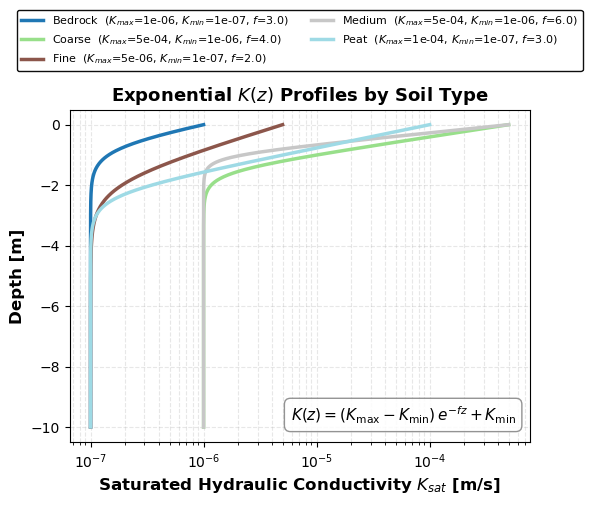

In [5]:
if plot:
    fig, ax = plt.subplots(figsize=(6, 6))

    soil_types = sorted(exp_params.keys())
    colors = plt.cm.tab20(np.linspace(0, 1, len(soil_types)))

    for color, soil_type in zip(colors, soil_types):
        params = exp_params[soil_type]
        z = np.linspace(0, max_depth_values[soil_type], 500)
        K = (params['Kmax'] - params['Kmin']) * np.exp(-params['f'] * z) + params['Kmin']

        ax.plot(
            K,
            -z,
            linewidth=2.5,
            color=color,
            label=(
                f"{soil_type}  ($K_{{max}}$={params['Kmax']:.0e}, "
                f"$K_{{min}}$={params['Kmin']:.0e}, $f$={params['f']})"
            ),
        )

    ax.set_xlabel('Saturated Hydraulic Conductivity $K_{sat}$ [m/s]', fontsize=12, fontweight='bold')
    ax.set_ylabel('Depth [m]', fontsize=12, fontweight='bold')
    ax.set_title('Exponential $K(z)$ Profiles by Soil Type', fontsize=13, fontweight='bold')
    ax.set_xscale('log')
    ax.grid(True, which='both', alpha=0.3, linestyle='--')
    ax.legend(
        loc='lower center',
        bbox_to_anchor=(0.5, 1.1),
        ncol=2,
        fontsize=8,
        framealpha=0.95,
        edgecolor='black',
    )

    ax.text(
        0.97, 0.05,
        r'$K(z) = (K_{\mathrm{max}} - K_{\mathrm{min}})\,e^{-fz} + K_{\mathrm{min}}$',
        transform=ax.transAxes,
        fontsize=11,
        ha='right', va='bottom',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85, edgecolor='gray'),
    )

    plt.tight_layout(rect=[0, 0, 1, 0.88])
    filename = os.path.join(fig_dir, 'deep_soil_exponential_profiles.png')
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

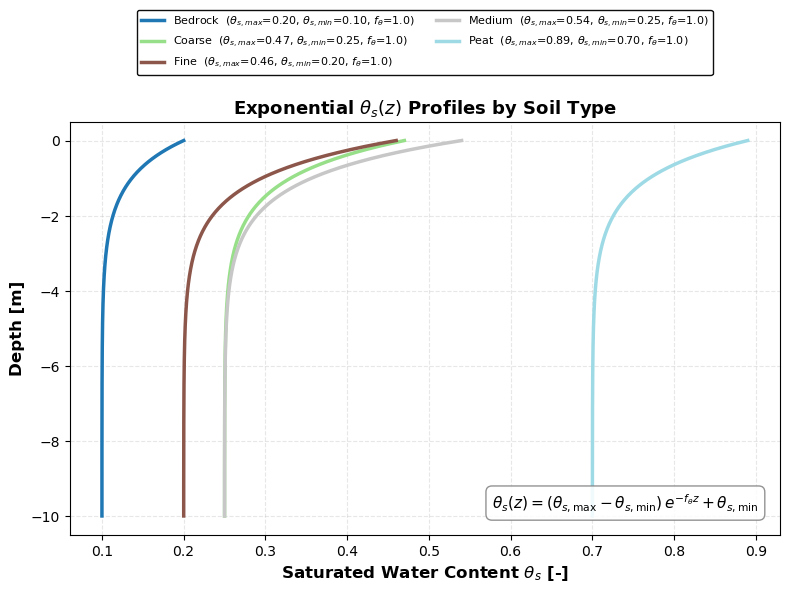

In [6]:
if exponential_ThetaS and plot:
    fig, ax = plt.subplots(figsize=(8, 7))

    soil_types = sorted(exp_params.keys())
    colors = plt.cm.tab20(np.linspace(0, 1, len(soil_types)))

    for color, soil_type in zip(colors, soil_types):
        params = exp_params[soil_type]
        z = np.linspace(0, params['max_depth'], 500)
        ThetaS = (params['ThetaS_max'] - params['ThetaS_min']) * np.exp(-params['f_theta'] * z) + params['ThetaS_min']

        ax.plot(
            ThetaS,
            -z,
            linewidth=2.5,
            color=color,
            label=(
                f"{soil_type}  ($\\theta_{{s,max}}$={params['ThetaS_max']:.2f}, "
                f"$\\theta_{{s,min}}$={params['ThetaS_min']:.2f}, $f_\\theta$={params['f_theta']})"
            ),
        )

    ax.set_xlabel('Saturated Water Content $\\theta_s$ [-]', fontsize=12, fontweight='bold')
    ax.set_ylabel('Depth [m]', fontsize=12, fontweight='bold')
    ax.set_title('Exponential $\\theta_s(z)$ Profiles by Soil Type', fontsize=13, fontweight='bold')
    ax.grid(True, which='both', alpha=0.3, linestyle='--')
    ax.legend(
        loc='lower center',
        bbox_to_anchor=(0.5, 1.1),
        ncol=2,
        fontsize=8,
        framealpha=0.95,
        edgecolor='black',
    )

    ax.text(
        0.97, 0.05,
        r'$\theta_s(z) = (\theta_{s,\mathrm{max}} - \theta_{s,\mathrm{min}})\,e^{-f_\theta z} + \theta_{s,\mathrm{min}}$',
        transform=ax.transAxes,
        fontsize=11,
        ha='right', va='bottom',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85, edgecolor='gray'),
    )

    plt.tight_layout(rect=[0, 0, 1, 0.88])
    filename = os.path.join(fig_dir, 'deep_soil_exponential_thetas_profiles.png')
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

In [7]:
deep_properties_exp = {}
for soil_type, props in deep_properties.items():
    params = exp_params[soil_type]
    depth_positive = discretized_depths(params['max_depth'])
    deep_z = np.round(-depth_positive, 3).tolist()
    n_layers = len(deep_z)

    deep_ksat_raw = (params['Kmax'] - params['Kmin']) * np.exp(-params['f'] * depth_positive) + params['Kmin']
    deep_ksat = [round_sig(value, sig_figs=3) for value in deep_ksat_raw.tolist()]

    # pF parameters: ThetaS either exponential or uniform
    pf_base = expand_pf_layers(props.get('pF', {}), n_layers)
    if exponential_ThetaS:
        thetas_raw = (params['ThetaS_max'] - params['ThetaS_min']) * np.exp(-params['f_theta'] * depth_positive) + params['ThetaS_min']
        pf_base['ThetaS'] = [round(v, 4) for v in thetas_raw.tolist()]

    deep_properties_exp[soil_type] = dict(props)
    deep_properties_exp[soil_type]['deep_z'] = deep_z
    deep_properties_exp[soil_type]['pF'] = pf_base
    deep_properties_exp[soil_type]['deep_ksat'] = deep_ksat

## 5. Build a `deep_properties`-Like Dictionary from the Exponential Parameters

This section keeps the exponential plotting separate and creates a new dictionary with the same structure as `deep_properties()`, but with discretized `deep_z` and computed `deep_ksat` values.

The discretization uses:
- 0.1 m intervals from 0 to 1 m
- 0.2 m intervals from 1 to 2 m
- 0.5 m intervals from 2 to 4 m
- 1.0 m intervals from 4 m to the assigned maximum depth

In [8]:
# Compute fc and wp from van Genuchten parameters in root_properties and
# assign them to both root_properties and org_properties.
print(f"{'Soil type':10s}  {'fc':>8}  {'wp':>8}")
print('-' * 32)
for soil_type in root_properties:
    pF = {
        'ThetaS': [root_properties[soil_type]['root_poros']],
        'ThetaR': [root_properties[soil_type]['root_wr']],
        'alpha':  [root_properties[soil_type]['root_alpha']],
        'n':      [root_properties[soil_type]['root_n']],
    }
    _, fc, wp = wrc(pF)
    root_properties[soil_type]['root_fc'] = round(fc, 4)
    root_properties[soil_type]['root_wp'] = round(wp, 4)
    org_properties[soil_type]['org_fc']   = round(fc, 4)
    org_properties[soil_type]['org_wp']   = round(wp, 4)
    print(f"  {soil_type:10s}  {fc:8.4f}  {wp:8.4f}")

Soil type         fc        wp
--------------------------------
  Bedrock       0.1597    0.0616
  Peat          0.4766    0.1584
  Fine          0.3722    0.2628
  Medium        0.2873    0.1169
  Coarse        0.1688    0.0437


In [9]:
org_code = org_properties_function_text(org_properties)
root_code = root_properties_function_text(root_properties)
deep_code = deep_properties_function_text(deep_properties_exp)

out_path = scripts_folder / 'soil_params.py'
out_path.write_text('\n\n'.join([org_code, root_code, deep_code]) + '\n', encoding='utf-8')
print(f'Written → {out_path}')

Written → /Users/jpnousu/Models/SpaFHy_v2.0/scripts/soil_params.py


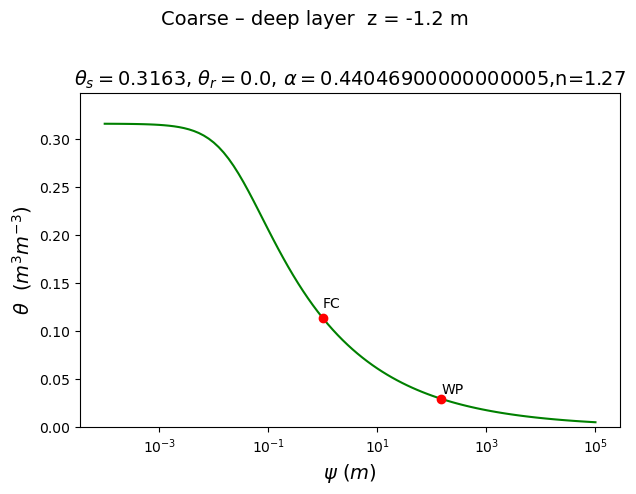

fc = 0.1136   wp = 0.0294


In [10]:
if plot == True:
    import matplotlib.pyplot as plt
    # ── User settings ─────────────────────────────────────────────────────────────
    layer      = 'deep'    # 'root' or 'deep'
    soil_type  = 'Coarse'  # 'Bedrock', 'Peat', 'Fine', 'Medium', 'Coarse'
    deep_layer = 10         # depth-layer index (0 = surface, -1 = deepest); only used for layer='deep'
    # ──────────────────────────────────────────────────────────────────────────────

    if layer == 'root':
        rp = root_properties[soil_type]
        pF = {
            'ThetaS': [rp['root_poros']],
            'ThetaR': [rp['root_wr']],
            'alpha':  [rp['root_alpha']],
            'n':      [rp['root_n']],
        }
        label = f"{soil_type} – root layer"

    elif layer == 'deep':
        dp  = deep_properties_exp[soil_type]
        z   = dp['deep_z'][deep_layer]
        pF  = {
            'ThetaS': [dp['pF']['ThetaS'][deep_layer]],
            'ThetaR': [dp['pF']['ThetaR'][deep_layer]],
            'alpha':  [dp['pF']['alpha'][deep_layer]],
            'n':      [dp['pF']['n'][deep_layer]],
        }
        label = f"{soil_type} – deep layer  z = {z} m"

    else:
        raise ValueError(f"layer must be 'root' or 'deep', got '{layer!r}'")

    _, fc, wp = wrc(pF, draw_pF=True)
    plt.gcf().suptitle(label, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    print(f"fc = {fc:.4f}   wp = {wp:.4f}")